### State Schema With DataClasses
When we define a LangGraph StateGraph, we use a state schema.

The state schema represents the structure and types of data that our graph will use.

All nodes are expected to communicate with that schema.

LangGraph offers flexibility in how you define your state schema, accommodating various Python types and validation approaches!


 we can use the TypedDict class from python's typing module.

It allows you to specify keys and their corresponding value types.

But, note that these are type hints.

They can be used by static type checkers (like mypy) or IDEs to catch potential type-related errors before the code is run.

But they are not enforced at runtime!

In [1]:
from typing_extensions import TypedDict
from typing import Literal

class TypeDictState(TypedDict):
    name:str
    game:Literal["cricket","tennis"]

In [2]:
def play_game(state:TypeDictState):
    print("------called play game node--------")
    return {"name":state["name"] + " want to play "}

def cricket(state:TypeDictState):
    print("------called cricket game node--------")
    return{"game":"cricket"}

def tennis(state:TypeDictState):
    print("------called tennis game node--------")
    return{"game":"tennis"}



In [3]:
import random
def decide_play(state:TypeDictState)->Literal["cricket","tennis"]:
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:
        return "cricket"
    else:
        return "tennis"

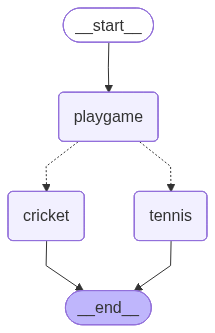

In [4]:

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder=StateGraph(TypeDictState)
builder.add_node("playgame",play_game)
builder.add_node("cricket",cricket)
builder.add_node("tennis",tennis)

## Flow of the graph

builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("tennis",END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [24]:
graph.invoke({"name":"Rahul"})

------called play game node--------
------called tennis game node--------


{'name': 'Rahul want to play ', 'game': 'tennis'}

Disadvantage of TypedDict

In [25]:
graph.invoke({"name":"1977"})

------called play game node--------
------called tennis game node--------


{'name': '1977 want to play ', 'game': 'tennis'}

even the name is string it is taking int as a parameter.It won't give error 

### Pydantic validation 

it check if the given input by llm is same as the datastructure mentioned


In [26]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel



In [27]:
class State(BaseModel):
    name:str

In [43]:
def example_node(state: State):
    return {"messages": state.name + " Hello"} #<-----This is a dict  

In [44]:
## stateGraph
builder=StateGraph(State)
builder.add_node("example_node",example_node)

builder.add_edge(START,"example_node")
builder.add_edge("example_node",END)

graph=builder.compile()

In [45]:
graph.invoke({"name": "Rahul"})

{'name': 'Rahul'}

In [46]:
graph.invoke({"name": 566})

ValidationError: 1 validation error for State
name
  Input should be a valid string [type=string_type, input_value=566, input_type=int]
    For further information visit https://errors.pydantic.dev/2.13/v/string_type